In [1]:
import sys
sys.path.append("../")

import numpy as np
np.random.seed(42)

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.ar_model import AutoReg
from data_loader import PairData

data = PairData("../../data/real_pair_ZC_ZW.csv")
n  = len(data)
q1 = n // 4
q3 = n // 2   # used for intercept/std calibration (closer to test period)
q4 = 3 * n // 4

# Beta from Q1 Johansen; intercept + std from Q3 (avoids food-crisis spike distorting scale)
jres      = coint_johansen(np.log(data.s[:, :q1]).T, det_order=0, k_ar_diff=1)
cv        = jres.evec[:, 0]
beta      = -cv[1] / cv[0]
intercept = float((np.log(data.s[0, q3:q4]) - beta * np.log(data.s[1, q3:q4])).mean())
spread_q3 = np.log(data.s[0, q3:q4]) - beta * np.log(data.s[1, q3:q4]) - intercept
fixed_std = float(spread_q3.std())
phi       = AutoReg(spread_q3, lags=1).fit().params[1]
wn_var    = fixed_std ** 2 * (1 - phi ** 2)

print(f"Pair: Corn (ZC) / Wheat (ZW)")
print(f"β={beta:.4f}  intercept={intercept:.4f} (from Q3)  std={fixed_std:.4f}  φ={phi:.4f}")
print(f"Training data (Q1-Q3): 0–{q4}  ({q4} steps)")
print(f"Real test (Q4): {q4}–{n}  ({n - q4} steps)")

N, T = 50, q4
log_s1 = np.cumsum(np.c_[np.full(N, np.log(100.0)),
                          0.0005 + 0.015 * np.random.randn(N, T - 1)], axis=1)
noise      = np.sqrt(wn_var) * np.random.randn(N, T)
spread_all = np.zeros((N, T))
for t in range(1, T):
    spread_all[:, t] = phi * spread_all[:, t - 1] + noise[:, t]

log_s0 = beta * log_s1 + intercept + spread_all
pairs  = np.stack([np.exp(log_s0), np.exp(log_s1)], axis=1)

print(f"Generated {N} synthetic series of length {T}  |  spread std: {spread_all.std(axis=1).mean():.4f} (target {fixed_std:.4f})")

Pair: Corn (ZC) / Wheat (ZW)
β=2.0433  intercept=-6.7315 (from Q3)  std=0.2110  φ=0.9902
Training data (Q1-Q3): 0–3771  (3771 steps)
Real test (Q4): 3771–5029  (1258 steps)
Generated 50 synthetic series of length 3771  |  spread std: 0.2031 (target 0.2110)


In [ ]:
%matplotlib widget

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from env import Market


class SyntheticMarket(gym.Wrapper):
    """On each reset, samples a new random synthetic series."""
    def __init__(self, pairs, **market_kwargs):
        self._pairs = pairs
        env = Market(self._make_pair(0), **market_kwargs)
        super().__init__(env)

    def _make_pair(self, idx):
        pd = object.__new__(PairData)
        pd.s = self._pairs[idx]
        pd.labels = ["ZC", "ZW"]
        pd.timestamps = np.arange(self._pairs.shape[2])
        return pd

    def reset(self, **kwargs):
        idx = np.random.randint(len(self._pairs))
        self.env._pair_data = self._make_pair(idx)
        return self.env.reset(**kwargs)


class FlatMarket(gym.Wrapper):
    """Obs: [position, |z|, |entry_z|, |spread|, |entry_spread|, macd, macd_signal, macd_hist, |rolling_mean|, rolling_std]."""
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(
            low= np.array([0.0, 0.0, 0.0, 0.0, 0.0, -np.inf, -np.inf, -np.inf, 0.0, 0.0], dtype=np.float32),
            high=np.array([1.0, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf], dtype=np.float32),
        )

    def _flatten(self, obs):
        return np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._flatten(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        return self._flatten(obs), reward, term, trunc, info


train_env = FlatMarket(SyntheticMarket(
    pairs,
    fixed_beta=beta,
    spread_intercept=intercept,
    fixed_std=fixed_std,
    reward_alpha=0.0,
    transaction_cost=0.004,
    
))

TOTAL_STEPS = N * T * 5
print(f"Training for {TOTAL_STEPS:,} steps  (epsilon-greedy exploration)...")

model = DQN("MlpPolicy", train_env, verbose=1,
            learning_rate=1e-4,
            buffer_size=100_000,
            learning_starts=2000,
            batch_size=64,
            gamma=0.999,
            exploration_fraction=0.6,
            exploration_final_eps=0.1,
            target_update_interval=500,
            train_freq=4)
model.learn(total_timesteps=TOTAL_STEPS)
print("Done.")

--- DQN ZC/ZW (real Q4 test) ---


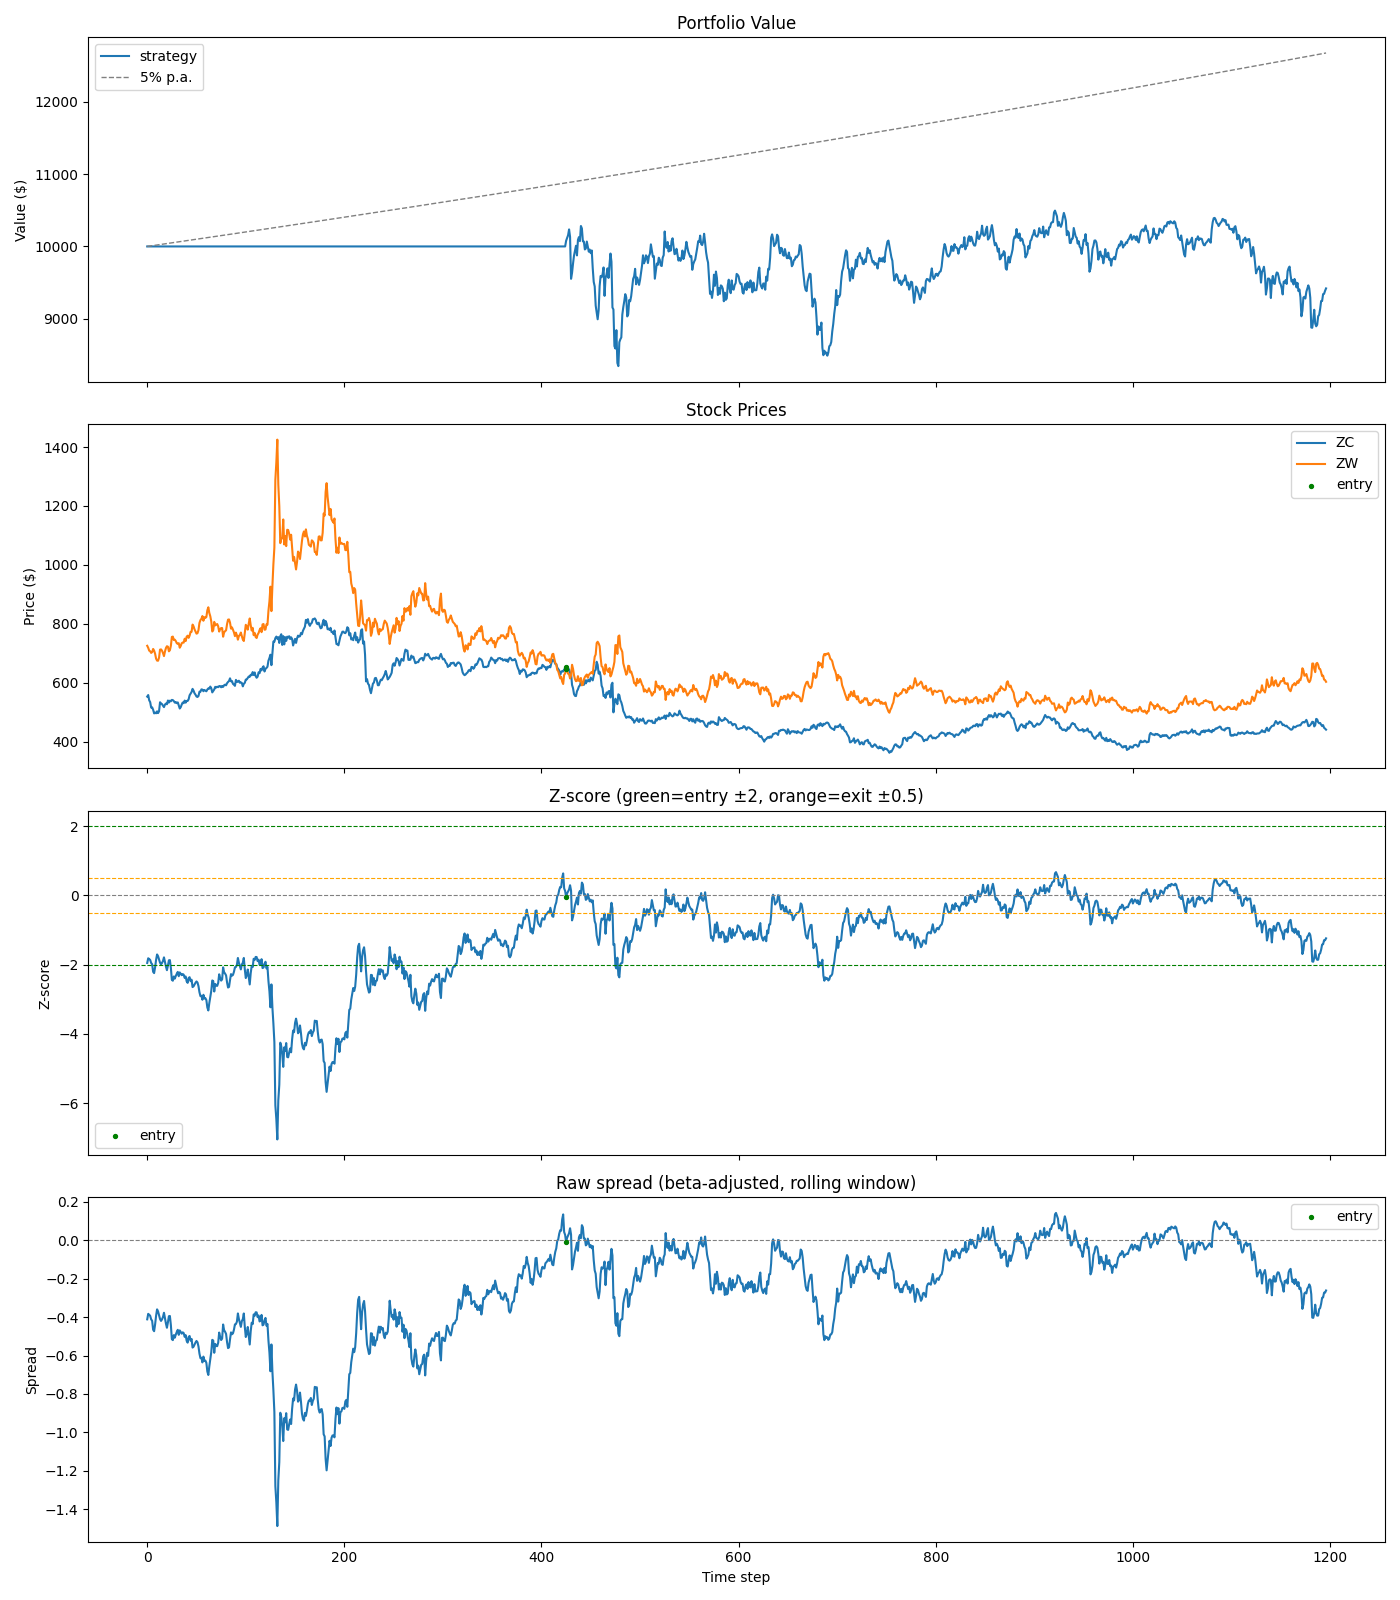

DQN — ZC/ZW real Q4
  Sharpe ratio      : -0.390
  Max drawdown      : -18.87%
  Annualised return : -1.25%

--- Z-score baseline (real Q4 test) ---


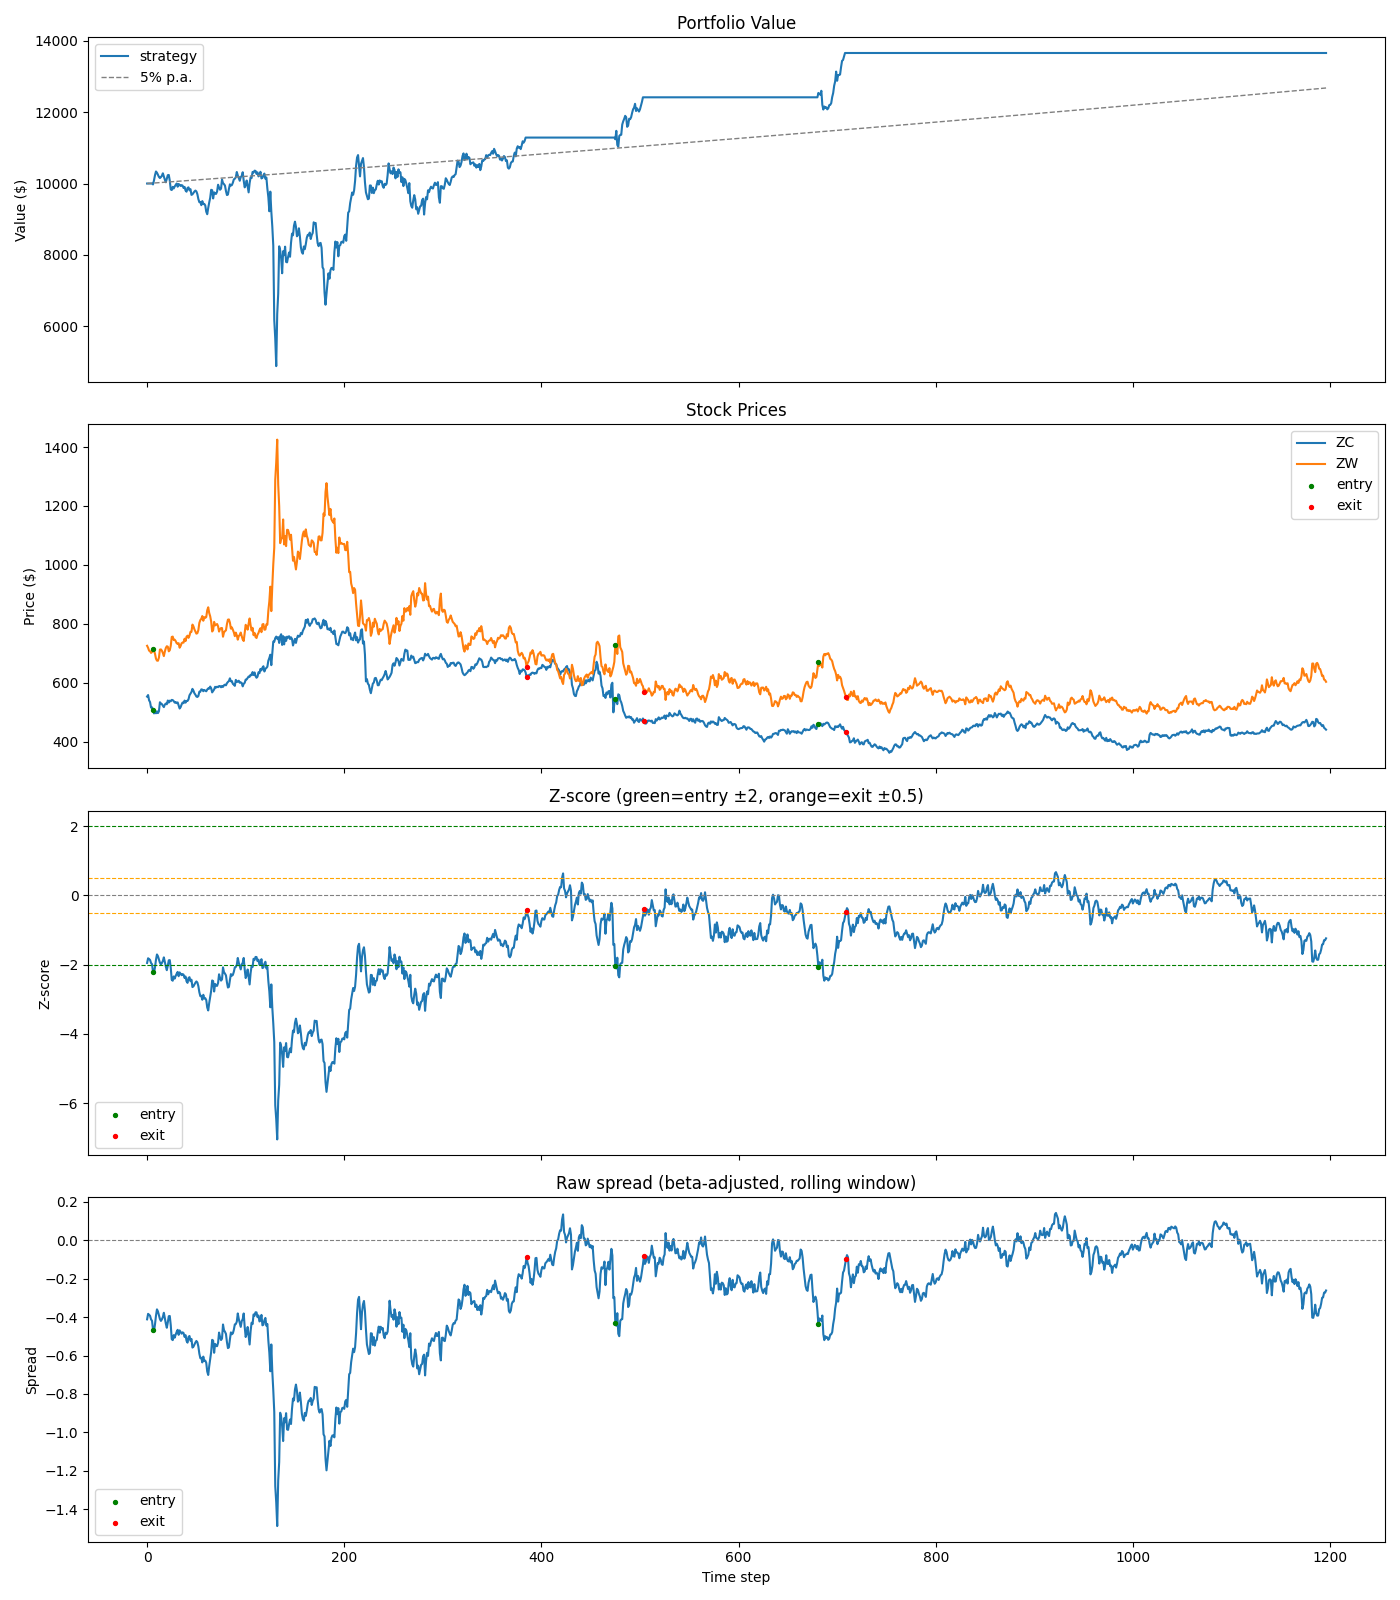

Z-score baseline — ZC/ZW real Q4
  Sharpe ratio      : 0.195
  Max drawdown      : -52.88%
  Annualised return : 6.78%



In [ ]:
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy


class SB3Agent:
    def __init__(self, model):
        self.model = model

    def predict(self, obs):
        flat = np.array([
            float(obs["position"]),
            abs(float(obs["spread_z_score"][0])),
            abs(float(obs["entry_z_score"][0])),
            abs(float(obs["spread"][0])),
            abs(float(obs["entry_spread"][0])),
            float(obs["macd"][0]),
            float(obs["macd_signal"][0]),
            float(obs["macd_hist"][0]),
            float(obs["rolling_mean"][0]),
            float(obs["rolling_std"][0]),
        ], dtype=np.float32)
        action, _ = self.model.predict(flat, deterministic=True)
        return int(action)


def metrics(results, label, rf_annual=0.05):
    pnl            = results["pnl"]
    n_days         = len(pnl)
    daily_returns  = np.diff(pnl) / pnl[:-1]
    excess_returns = daily_returns - rf_annual / 252
    sharpe         = excess_returns.mean() / (excess_returns.std() + 1e-12) * np.sqrt(252)
    running_max    = np.maximum.accumulate(pnl)
    max_drawdown   = ((pnl - running_max) / running_max).min()
    total_return   = (pnl[-1] - pnl[0]) / pnl[0]
    ann_return     = (1 + total_return) ** (252 / n_days) - 1
    print(f"{label}")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Max drawdown      : {max_drawdown*100:.2f}%")
    print(f"  Annualised return : {ann_return*100:.2f}%")
    print()


env_kwargs = dict(fixed_beta=beta, spread_intercept=intercept, fixed_std=fixed_std)

q4_data = data.slice(q4)
results_dqn_q4 = run_strategy(Market(q4_data, **env_kwargs), SB3Agent(model))
print("--- DQN ZC/ZW (real Q4 test) ---")
plot_strategy(results_dqn_q4)
metrics(results_dqn_q4, "DQN \u2014 ZC/ZW real Q4")

results_base_q4 = run_strategy(Market(q4_data, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline (real Q4 test) ---")
plot_strategy(results_base_q4)
metrics(results_base_q4, "Z-score baseline \u2014 ZC/ZW real Q4")

--- DQN on synthetic ZC/ZW series 0 ---


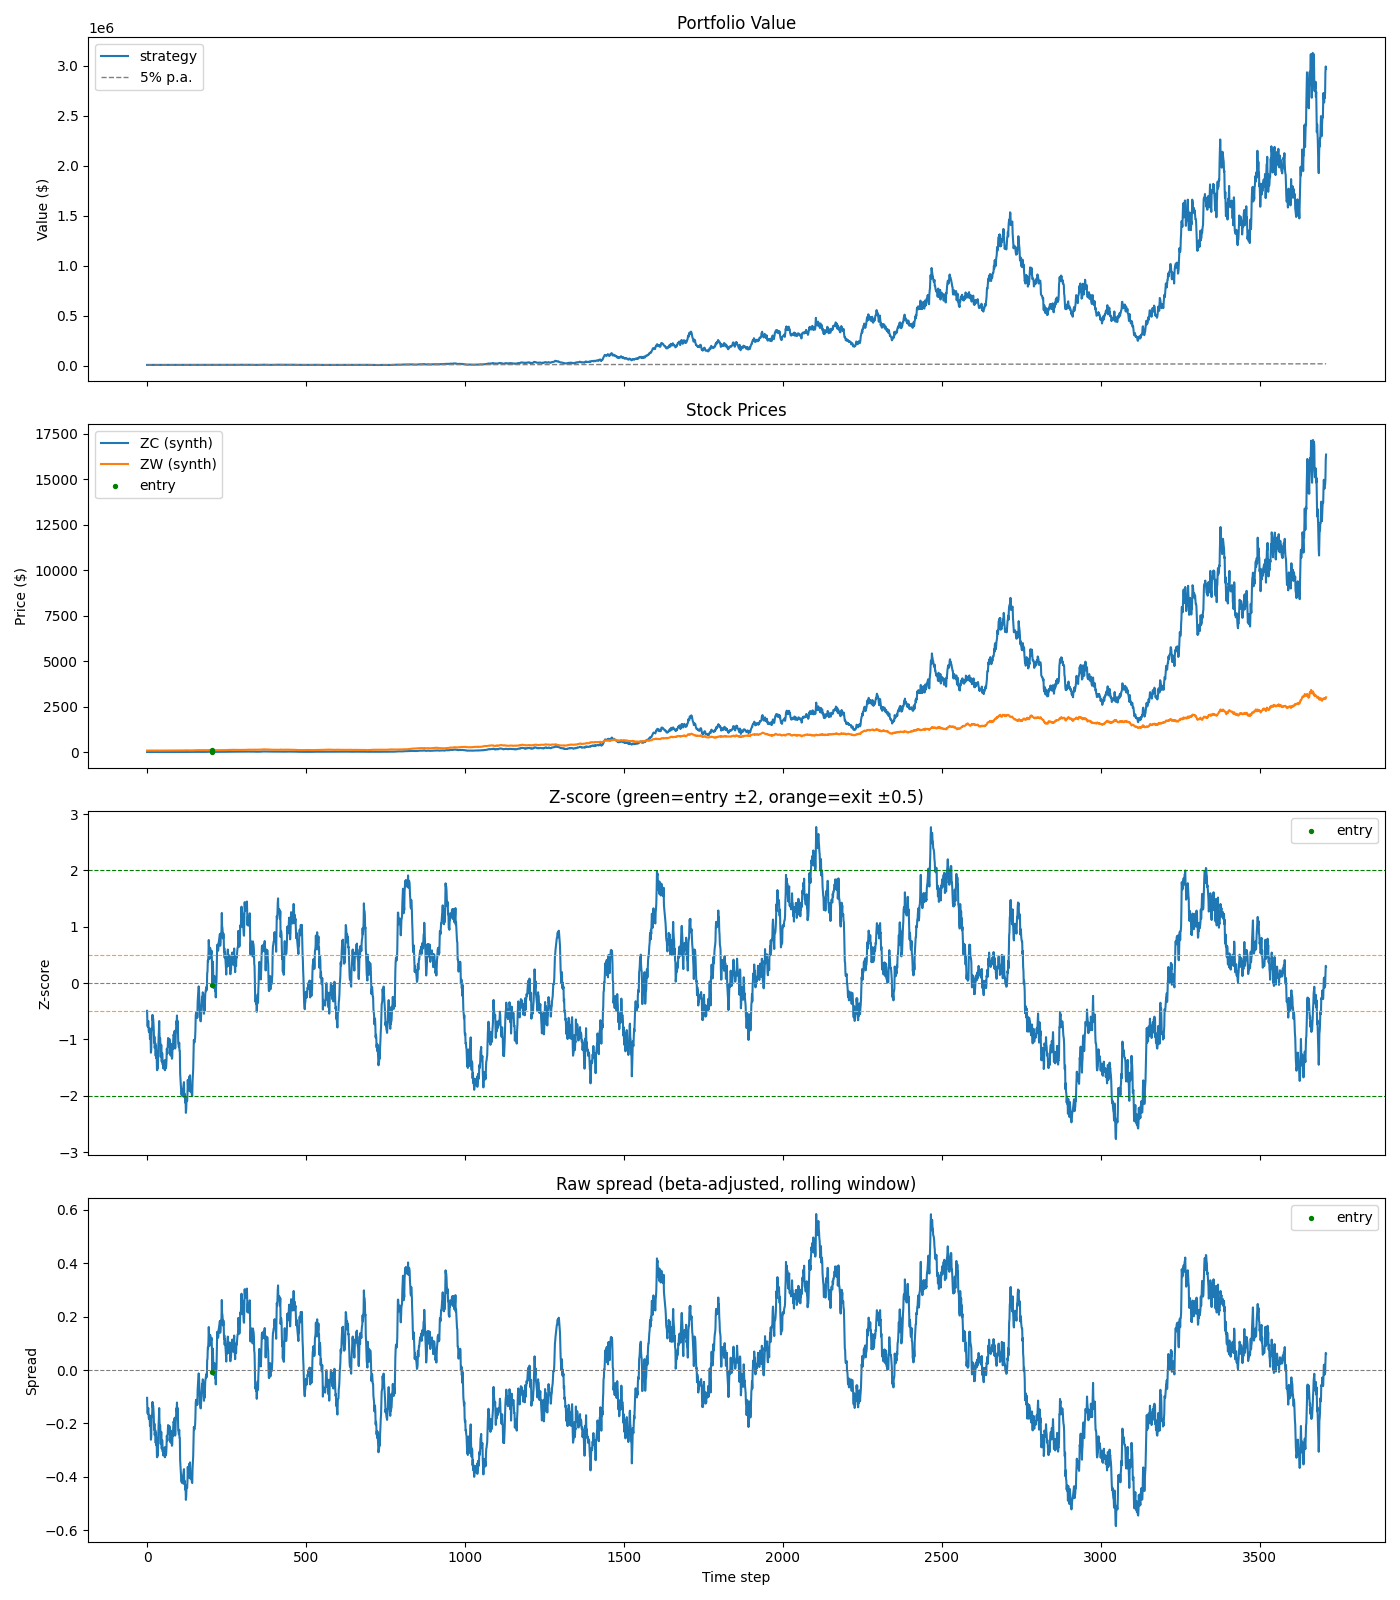

DQN — ZC/ZW synthetic series 0
  Sharpe ratio      : 0.835
  Max drawdown      : -83.69%
  Annualised return : 47.21%

--- Z-score baseline on synthetic ZC/ZW ---


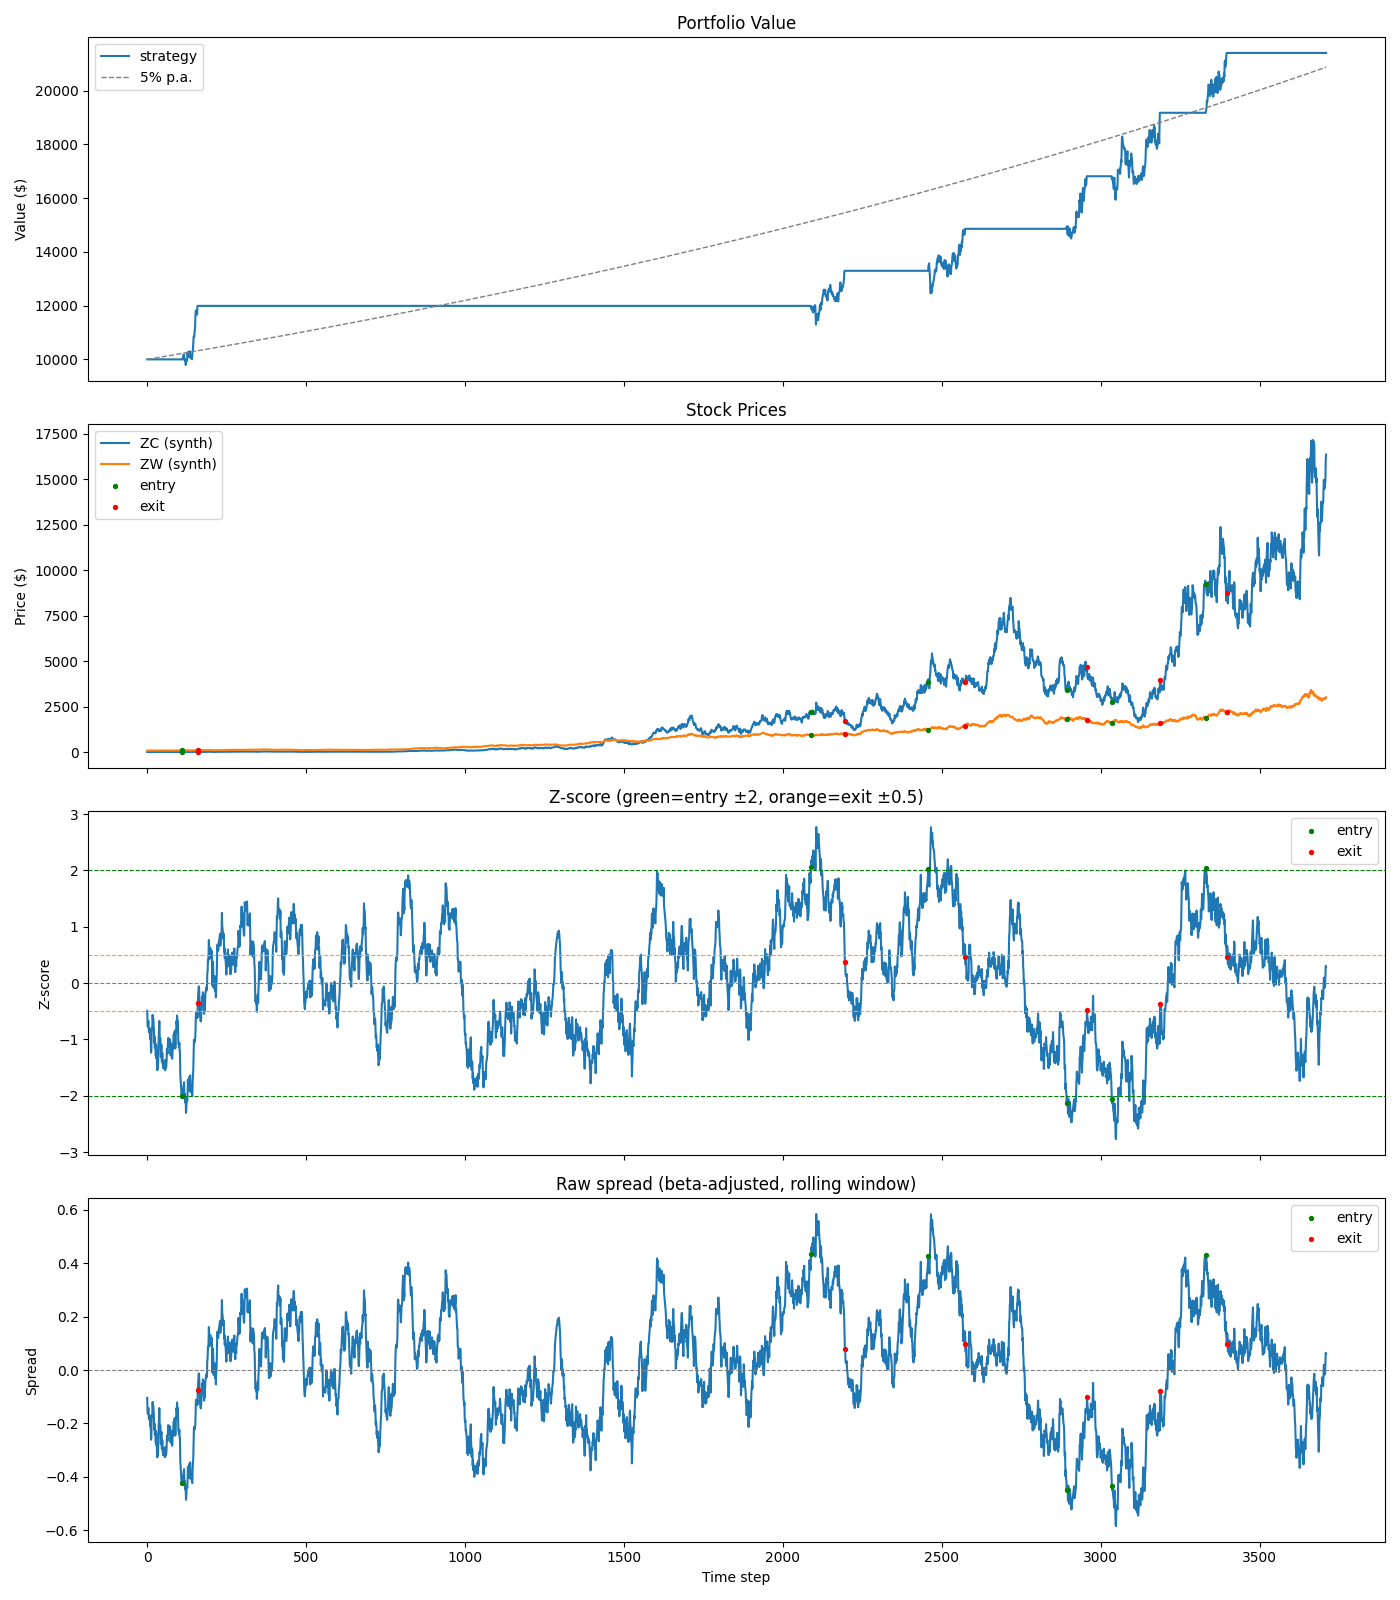

Z-score baseline — ZC/ZW synthetic series 0
  Sharpe ratio      : 0.059
  Max drawdown      : -9.62%
  Annualised return : 5.31%



In [ ]:
# DQN on a single synthetic series (series 0)
synth_pair = object.__new__(PairData)
synth_pair.s = pairs[0]
synth_pair.labels = ["ZC (synth)", "ZW (synth)"]
synth_pair.timestamps = np.arange(pairs.shape[2])

results_dqn_synth = run_strategy(Market(synth_pair, **env_kwargs), SB3Agent(model))
print("--- DQN on synthetic ZC/ZW series 0 ---")
plot_strategy(results_dqn_synth)
metrics(results_dqn_synth, "DQN \u2014 ZC/ZW synthetic series 0")

results_base_synth = run_strategy(Market(synth_pair, **env_kwargs), ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
print("--- Z-score baseline on synthetic ZC/ZW ---")
plot_strategy(results_base_synth)
metrics(results_base_synth, "Z-score baseline \u2014 ZC/ZW synthetic series 0")

--- DQN on unseen synthetic ZC/ZW ---


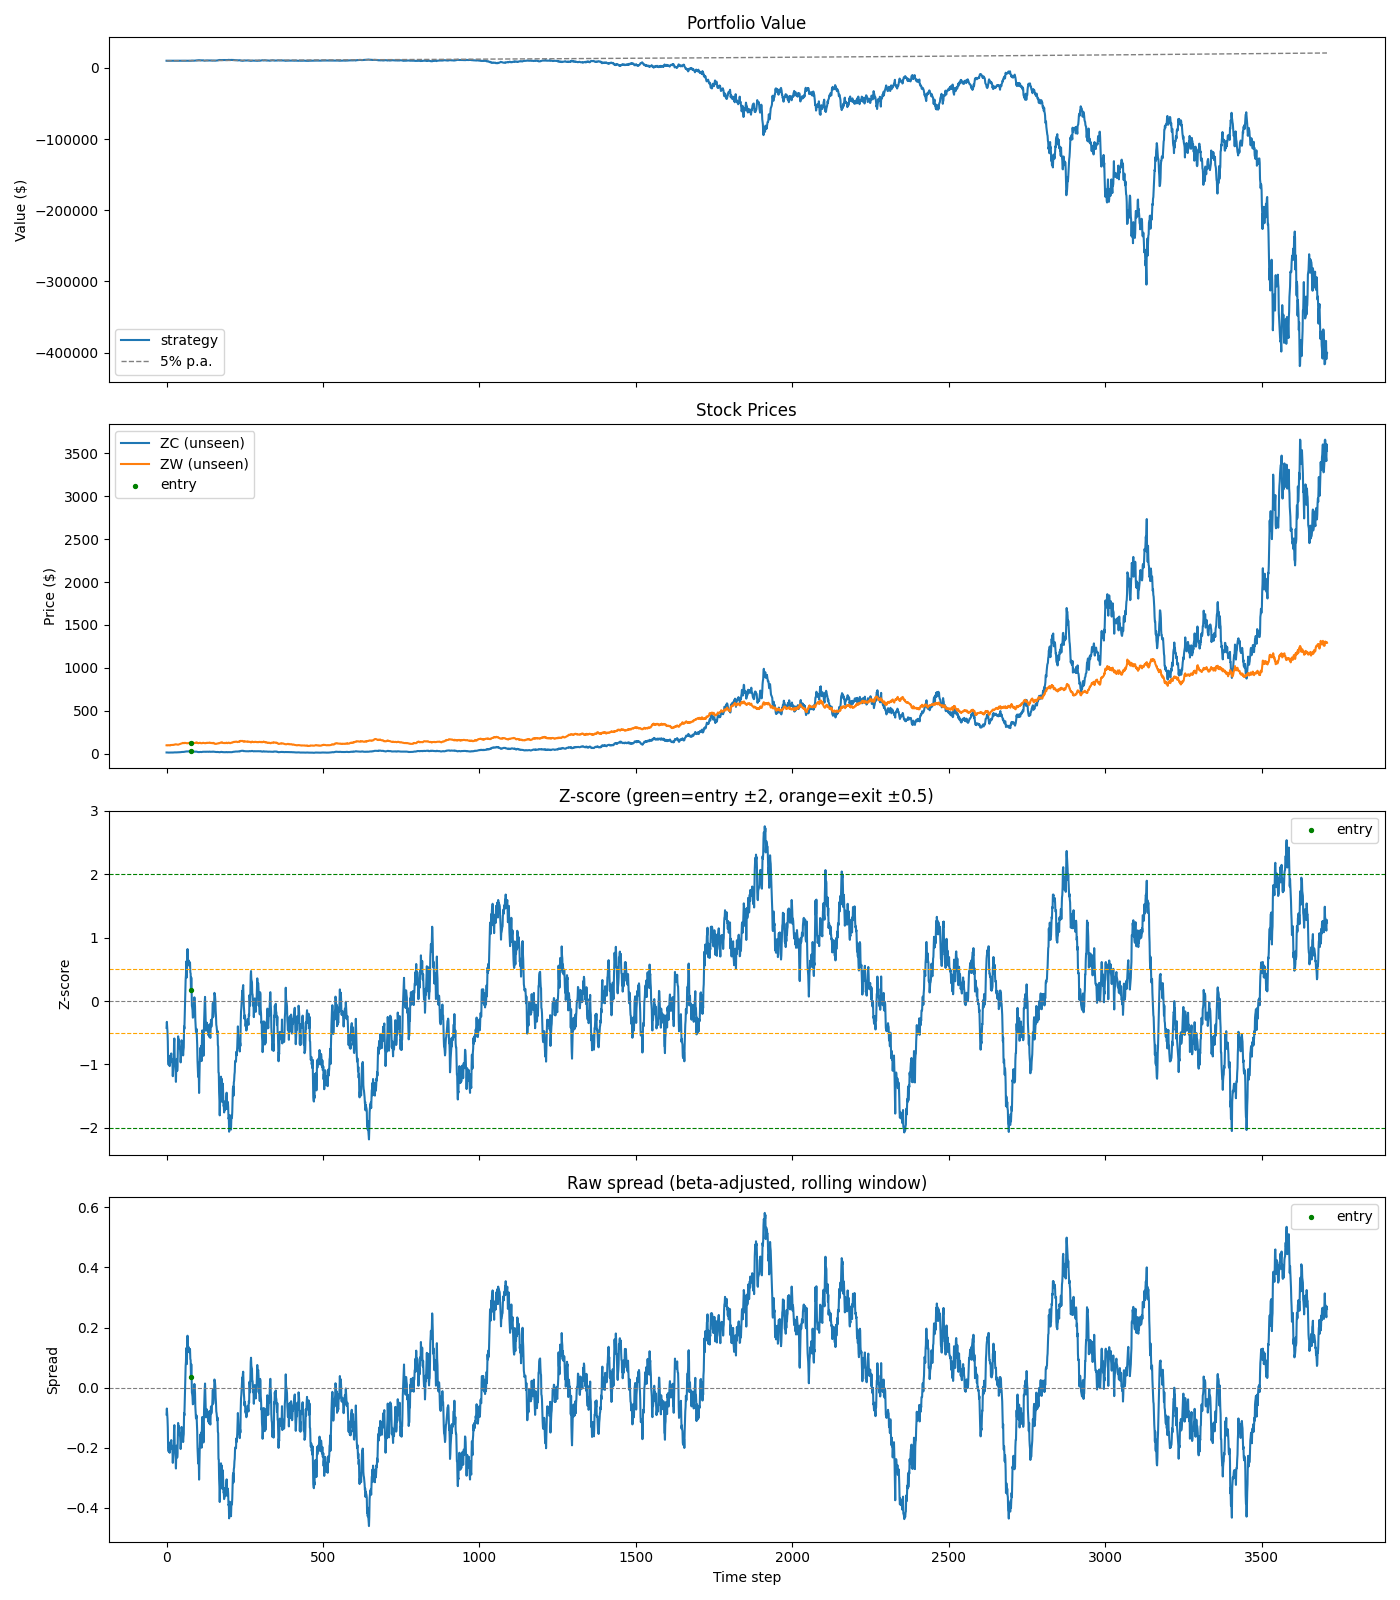

DQN — ZC/ZW unseen synthetic
  Sharpe ratio      : 0.309
  Max drawdown      : -3688.87%
  Annualised return : nan%



/tmp/ipykernel_35125/3790587132.py:35: RuntimeWarning: invalid value encountered in scalar power
  ann_return     = (1 + total_return) ** (252 / n_days) - 1


In [ ]:
# Unseen synthetic series (different seed, never seen during training)
rng_test = np.random.default_rng(999)
log_s1_u = np.cumsum(np.c_[np.full(1, np.log(100.0)),
                 0.0005 + 0.015 * rng_test.standard_normal((1, T - 1))], axis=1)
noise_u  = np.sqrt(wn_var) * rng_test.standard_normal((1, T))
spr_u    = np.zeros((1, T))
for t in range(1, T):
    spr_u[:, t] = phi * spr_u[:, t - 1] + noise_u[:, t]
log_s0_u = beta * log_s1_u + intercept + spr_u
pairs_u  = np.stack([np.exp(log_s0_u), np.exp(log_s1_u)], axis=1)

unseen = object.__new__(PairData)
unseen.s = pairs_u[0]
unseen.labels = ["ZC (unseen)", "ZW (unseen)"]
unseen.timestamps = np.arange(pairs_u.shape[2])

results_dqn_u = run_strategy(Market(unseen, **env_kwargs), SB3Agent(model))
print("--- DQN on unseen synthetic ZC/ZW ---")
plot_strategy(results_dqn_u)
metrics(results_dqn_u, "DQN \u2014 ZC/ZW unseen synthetic")